# PyTorch MLP on EEG bandpower features

**What this notebook is.** A demo training a small set of EEG data. The pipeline attempts to mirror the classifiers in `src/analysis/`, but using PyTorch for Neuronal Network classification.

**Disclaimer:** The original sklearn classifiers were trained on lab-internal BioMag data (results reported in a separate thesis). That data isn't available due to data privacy constraints, so this notebook uses MNE's built-in `eegbci` motor-imagery dataset.


**To run this notebook.** Activate the conda env (`conda activate mtbi_meeg_conda`), pick that kernel in VS Code or `jupyter`, and Run All. First execution might be slow since it downloads ~5 MB of data into `~/mne_data/`.

Resources:
https://github.com/rasbt/machine-learning-book?
https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html
Check https://www.youtube.com/watch?v=JHWqWIoac2I

## 1. Environment setup

import libraries and define seed and other things

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import mne
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Silence MNE excesssive verbose logging 
mne.set_log_level('WARNING')

## 2. Load data

We use 20 subjects, 2 runs each from the EEG Motor Movement/Imagery Dataset, sampled at 160Hz and epochs of 1min
- Run 1: baseline eyes-open (label 0)
- Run 2: baseline eyes-closed (label 1)

NOTE: loading the data might take up to 10min

In [7]:
N_SUBJECTS = 20
RUNS = [1, 2]  # 1 = eyes open, 2 = eyes closed

# Load data function as 3-uples [data, eyes, sampling_freq]
def load_subject(subject_id: int) -> list[tuple[np.ndarray, int, float]]:
    """Load both runs for one subject. Returns list of (raw_data, label, sfreq)."""
    paths = mne.datasets.eegbci.load_data(subject_id, RUNS, update_path=True)
    out = []
    for path, label in zip(paths, [0, 1]):
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
        out.append((raw.get_data(), label, raw.info['sfreq']))
    return out

# Iterate over subjects and extend into a 1D array of 3-uples
samples = []
for subj in range(1, N_SUBJECTS + 1):
    samples.extend(load_subject(subj))

print(f'Loaded {len(RUNS)} runs for each of the {N_SUBJECTS} subjects')
print(f'Shape of first sample: {samples[0][0].shape}  (channels x timepoints)')

Loaded 2 runs for each of the 20 subjects
Shape of first sample: (64, 9760)  (channels x timepoints)


## 3. Feature extraction — bandpower

Following the same approach as `src/processing/04_bandpower.py`: for each run, compute the average power in the EEG frequency bands per channel. This yields a `(n_channels × n_bands)` feature matrix per run, which we flatten to a 1D vector.

Bands used here: delta (1-4 Hz), theta (4-8), alpha (8-13), beta (13-30), gamma (30-45). Standard clinical EEG bands.

In [8]:
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

# Naming convention reminder
# - UPPER_CASE: constants, don't change after definition.
# e.g. SEED, N_SUBJECTS, RUNS,  BANDS
# - snake_case: regular variables and functions
# e.g. samples, psd, freqs, n_channels, features, bandpower_features

def bandpower_features(raw_data: np.ndarray, sfreq: float) -> np.ndarray:
    """Compute bandpower per channel per band, return flattened (n_channels * n_bands,) vector."""
    # Welch's function: split signal into small freq windows, FFT each, then average.
    # Returns (psd, freqs):
    #   psd  [shape is (n_channels, n_freqs)]: power at each freq step, and per channel.
    #   freqs [shape is (n_freqs,)]: the actual Hz values for each column of psd
    psd, freqs = mne.time_frequency.psd_array_welch(raw_data, sfreq=sfreq, fmin=1, fmax=45)

    n_channels = psd.shape[0]
    features = np.zeros((n_channels, len(BANDS)))

    for band_idx, band_name in enumerate(BANDS):
        fmin, fmax = BANDS[band_name]
        # Define a mask for each band: True wherever the freq falls inside this band's range, False otherwise

        mask = (freqs >= fmin) & (freqs < fmax)
        # Sum over the freqs where mask is True

        features[:, band_idx] = psd[:, mask].sum(axis=1)
    return features.flatten()
                                     

# np.stack stacks a list of 1D arrays into a 2D array.
X = np.stack([bandpower_features(data, sfreq) for data, _, sfreq in samples])
y = np.array([label for _, label, _ in samples])

# Check the shapes before training.
print(f'X shape: {X.shape}')   # expect (40, 320)
print(f'y shape: {y.shape}, classes: {np.unique(y, return_counts=True)}')



X shape: (40, 320)
y shape: (40,), classes: (array([0, 1]), array([20, 20]))


## 3.1 Some data visualization

sampling freq (Hz): 160.0
psd shape: (64, 71)
freqs shape: (71,)
first 10 freqs (Hz): [1.25  1.875 2.5   3.125 3.75  4.375 5.    5.625 6.25  6.875]
alpha-band freqs: [ 8.125  8.75   9.375 10.    10.625 11.25  11.875 12.5  ]


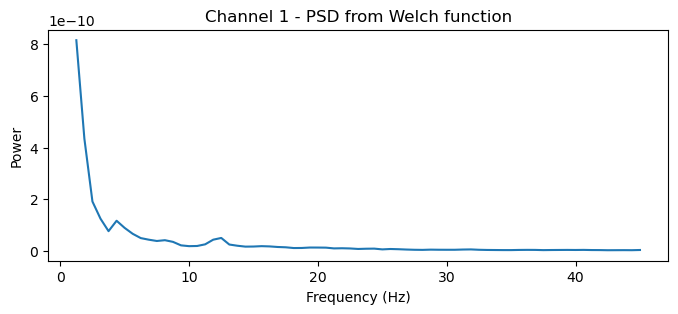

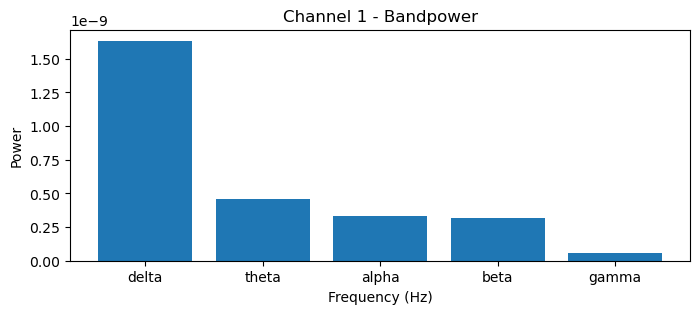

In [13]:
# First 3-uple of samples
data_0, _, sfreq_0 = samples[0]
psd, freqs = mne.time_frequency.psd_array_welch(data_0, sfreq=sfreq_0, fmin=1, fmax=45)
print("sampling freq (Hz):", sfreq_0)
print("psd shape:", psd.shape)             # (64, ~72)
print("freqs shape:", freqs.shape)          # (~72,)
print("first 10 freqs (Hz):", freqs[:10])
print("alpha-band freqs:", freqs[(freqs >= 8) & (freqs < 13)])

# Plot channel 1's Welch PSD
plt.figure(figsize=(8, 3))
plt.plot(freqs, psd[0])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Channel 1 - PSD from Welch function')
plt.show()

# Plot channel 1's band spectrum
plt.figure(figsize=(8, 3))
plt.bar(['delta','theta','alpha','beta','gamma'], X[0][5:10])
plt.title('Channel 1 - Bandpower')
plt.ylabel('power')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.show()
plt.show()

## 4. Train / test split

20 subjects and a 80/20 split? 85/15?

In [9]:
# Group split by subject ID so a subject's two runs end up on the same side
subject_ids = np.repeat(np.arange(1, N_SUBJECTS + 1), len(RUNS))
from sklearn.model_selection import GroupShuffleSplit
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=subject_ids))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (32, 320), Test: (8, 320)


## 5. Model

A 2 layer MLP? Input would be the bandpower feature vector (n_channels × n_bands), output is a binary classification.




In [17]:
class MLP(nn.Module):
    # Define model architecture
    def __init__(self, input_dim=320, hidden_dim=64, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.out = nn.Linear(hidden_dim, out_features)
    # Forward method
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.relu(x)
        x = self.out(x)
        return x

model = MLP(input_dim=X_train.shape[1])
print(model)

MLP(
  (fc1): Linear(in_features=320, out_features=64, bias=True)
  (relu): ReLU()
  (out): Linear(in_features=64, out_features=1, bias=True)
)


## 6. Define training

In [18]:
# how many full passes over the training data to do.
N_EPOCHS = 100
# learning rate. The step size the optimizer takes when updating parameters.
LR = 1e-3

def train(model, X_train, y_train, X_test, y_test, n_epochs=N_EPOCHS, lr=LR):
    """Train the model, return loss and accuracy history."""
    # Convert numpy arrays to torch tensors, move to device
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train,  dtype=torch.float32).reshape(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


    #Loss and optimizer
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    # Record of of the progress
    history = {'train_loss': [], 'test_loss': [], 'test_accuracy': []}

    for epoch in range(n_epochs):
        # training setup
        model.train()
        optimizer.zero_grad() ## Super important!
        train_logits = model(X_train_tensor)
        train_loss = loss_fn(train_logits, y_train_tensor)
        train_loss.backward() ## Maybe add the definiton of backward somewhere?
        optimizer.step()

        # evaluation on test
        model.eval()
        with torch.no_grad(): #disable autograd tracking, important if needing to call backwards()
            test_logits = model(X_test_tensor)
            test_loss = loss_fn(test_logits, y_test_tensor)
            test_preds = (test_logits > 0).float() ## Convert logit to binary
            test_acc = (test_preds == y_test_tensor).float().mean().item()
        
        history['train_loss'].append(train_loss.item())
        history['test_loss'].append(test_loss.item())
        history['test_accuracy'].append(test_acc)
    # store these to understand model fitting
    history['final_test_preds'] = test_preds.cpu().numpy().flatten()
    history['final_test_targets'] = y_test_tensor.cpu().numpy().flatten()

    return history

# Check the model is real and has parameters
print("Model params BEFORE training:")
for name, p in model.named_parameters():
    print(f"  {name}: shape={tuple(p.shape)}, requires_grad={p.requires_grad}, sum={p.sum().item():.4f}")
print(f"Total params: {sum(p.numel() for p in model.parameters())}")




Model params BEFORE training:
  fc1.weight: shape=(64, 320), requires_grad=True, sum=2.3748
  fc1.bias: shape=(64,), requires_grad=True, sum=-0.0716
  out.weight: shape=(1, 64), requires_grad=True, sum=0.6640
  out.bias: shape=(1,), requires_grad=True, sum=0.0966
Total params: 20609


## 7. Evaluation

Train model on the data and check the outcome

In [19]:
history = train(model, X_train, y_train, X_test, y_test)
print(f"Final train loss: {history['train_loss'][-1]:.3f}")
print(f"Final test loss: {history['test_loss'][-1]:.3f}")
print(f"Final test acc: {history['test_accuracy'][-1]:.3f}")

print("test_preds:", history['final_test_preds'])
print("y_test:    ", history['final_test_targets'])
print("unique preds:", np.unique(history['final_test_preds']))
print(f"train_loss epoch 0:  {history['train_loss'][0]:.4f}")
print(f"train_loss epoch 99: {history['train_loss'][-1]:.4f}")

Final train loss: 0.693
Final test loss: 0.693
Final test acc: 0.500
test_preds: [1. 1. 1. 1. 1. 1. 1. 1.]
y_test:     [0. 1. 0. 1. 0. 1. 0. 1.]
unique preds: [1.]
train_loss epoch 0:  0.6946
train_loss epoch 99: 0.6931


## 9. Next steps

What would come next if this had more time:
- Hopefully this is more or less successful 
- Better understanding on some of the choices (n_epochs, data structure, etc)
- Implement k-fold CV
- Run on real mTBI data: e.g., the one from BioMag used for the sklearn classifiers or an open source one like OpenNeuro `ds005114`
- Compare performance against the sklearn classifiers on the same dataset used for them in the thesis.